In [69]:
# Amazon Product Review Sentiment Analysis using Machine Learning

---

## Project Overview

Customer reviews play a vital role in helping businesses understand customer satisfaction and improve their products. Manually analyzing thousands of reviews is difficult and time-consuming.

This project uses Natural Language Processing (NLP) and Machine Learning techniques to automatically classify Amazon product reviews as either Positive or Negative.

The project demonstrates the complete machine learning workflow including:

- Data Exploration
- Data Cleaning
- Text Preprocessing
- Feature Engineering using TF-IDF
- Machine Learning Model Building
- Model Evaluation
- Sentiment Prediction

The final model can automatically predict the sentiment of unseen Amazon product reviews.

SyntaxError: invalid syntax (3179825282.py, line 3)

In [ ]:
# Problem Statement

The objective of this project is to build an intelligent machine learning model capable of classifying Amazon product reviews into positive or negative sentiments.

Businesses receive thousands of customer reviews every day. Understanding customer opinions manually is difficult and expensive.

This project automates sentiment analysis using Natural Language Processing (NLP), allowing businesses to quickly understand customer feedback and make informed decisions.

In [68]:
# Dataset Information

Dataset Name:
Amazon Product Reviews Dataset

Dataset Size:
10,000 Reviews

File Format:
TSV (Tab Separated Values)

Target Variable:
label

Input Variable:
review

Classes:

Positive Review → pos

Negative Review → neg

SyntaxError: invalid character '→' (U+2192) (831096712.py, line 20)

In [ ]:
# Import Required Libraries

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing

import nltk

from nltk.corpus import stopwords

from nltk.stem import PorterStemmer

from nltk.tokenize import word_tokenize

import re

# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import cross_val_score

# Word Cloud

from wordcloud import WordCloud

# Ignore Warnings

import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Download NLTK Resources

In [20]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Load Dataset

In [4]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")

In [ ]:
# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the structure, quality, and characteristics of the dataset before building a machine learning model.

In this section, we will:

- Inspect the dataset
- Check missing values
- Analyze class distribution
- Explore review lengths
- Visualize important dataset characteristics

In [5]:
df.head(10)

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
5,pos,an absolute masterpiece: I am quite sure any o...
6,neg,"Buyer beware: This is a self-published book, a..."
7,pos,Glorious story: I loved Whisper of the wicked ...
8,pos,A FIVE STAR BOOK: I just finished reading Whis...
9,pos,Whispers of the Wicked Saints: This was a easy...


In [6]:
print("Dataset Shape:", df.shape)
print("\n")

print("Column Names:")
print(df.columns.tolist())

Dataset Shape: (10000, 2)


Column Names:
['label', 'review']


In [7]:
df.sample(5, random_state=42)

,label,review
6252,neg,"I Know I'm in the Minority Here, But...: I'm s..."
4684,neg,Disappointing: This is the 4th Clavell book I'...
1731,neg,"The writing is good, but the plot needs a lot ..."
4742,neg,"Good for a little while, but....: Sure, this t..."
4521,neg,Great For First Timers: While the flexability ...


In [ ]:
## Check for Missing Values

In [8]:
missing_values = df.isnull().sum()

missing_values

,0
label,0
review,0


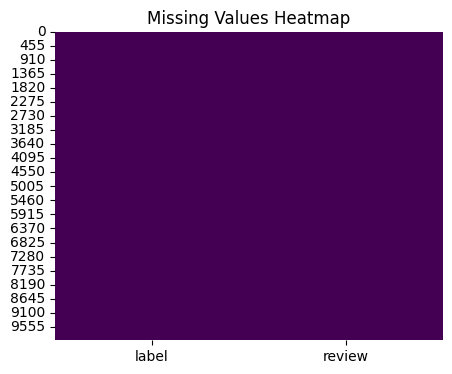

In [9]:
plt.figure(figsize=(5,4))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [ ]:
## Class Distribution

In [10]:
df['label'].value_counts()

,count
label,
neg,5097
pos,4903


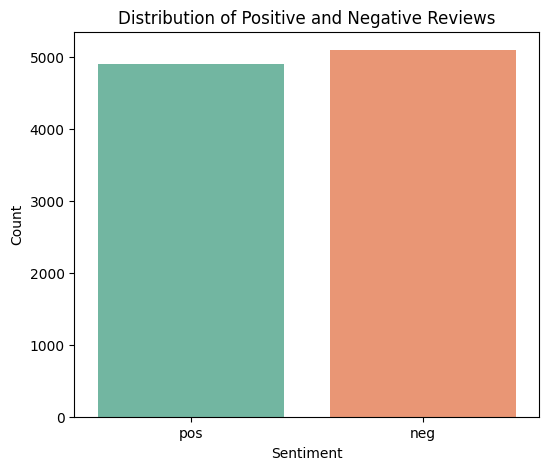

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="label",
    hue="label",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Positive and Negative Reviews")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [ ]:
## Review Length Analysis

In [12]:
df["review_length"] = df["review"].apply(len)

df.head()

,label,review,review_length
0,pos,Stuning even for the non-gamer: This sound tra...,426
1,pos,The best soundtrack ever to anything.: I'm rea...,509
2,pos,Amazing!: This soundtrack is my favorite music...,760
3,pos,Excellent Soundtrack: I truly like this soundt...,743
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",481


In [13]:
df["review_length"].describe()

,review_length
count,10000.000000
mean,438.695400
std,239.241132
min,101.000000
25%,238.000000
50%,391.000000
75%,605.000000
max,1015.000000


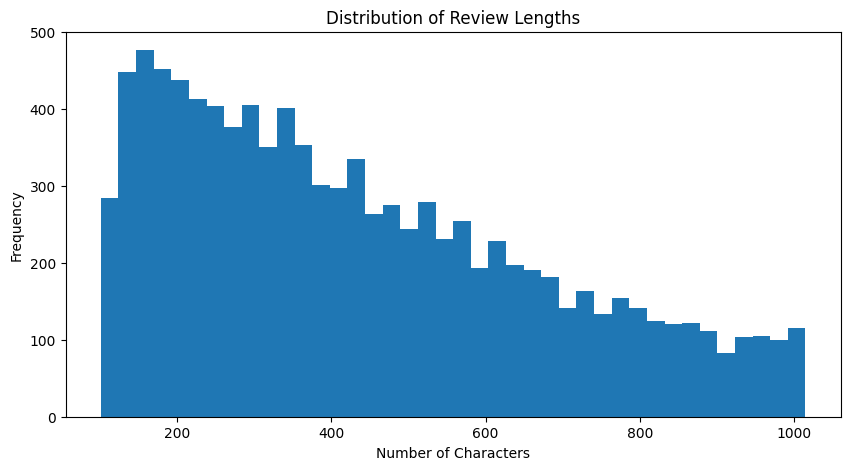

In [14]:
plt.figure(figsize=(10,5))

plt.hist(df["review_length"], bins=40)

plt.title("Distribution of Review Lengths")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

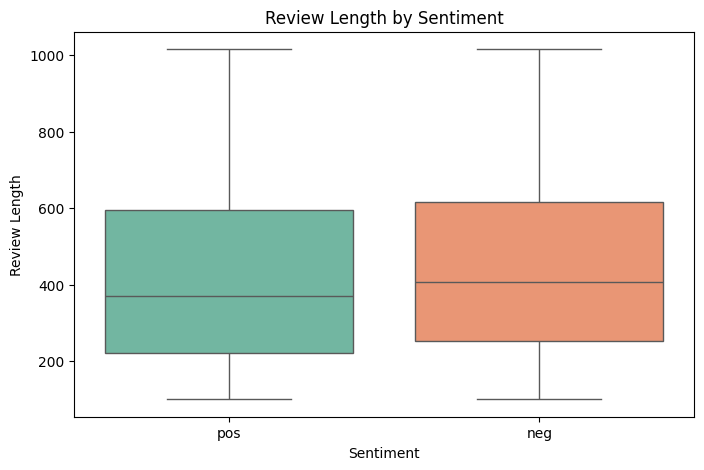

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="label",
    y="review_length",
    hue="label",
    palette="Set2",
    legend=False
)

plt.title("Review Length by Sentiment")

plt.xlabel("Sentiment")

plt.ylabel("Review Length")

plt.show()

In [ ]:
## Observations

From the exploratory data analysis:

- The dataset contains two sentiment classes: positive and negative.
- Missing values were checked before preprocessing.
- The class distribution is balanced.
- Review lengths vary considerably, indicating a mix of short and detailed customer feedback.
- The dataset is suitable for sentiment classification using machine learning techniques.

In [ ]:
# Text Preprocessing

Raw customer reviews often contain unnecessary information such as punctuation, numbers, HTML tags, URLs, and stopwords.

Before training a machine learning model, the text must be cleaned and transformed into a consistent format.

The preprocessing pipeline implemented in this project includes:

- Convert text to lowercase
- Remove HTML tags
- Remove URLs
- Remove punctuation
- Remove numbers
- Remove extra spaces
- Remove stopwords
- Apply stemming

In [ ]:
## Initialize NLP Components

In [16]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

In [ ]:
## Define Text Preprocessing Function

In [17]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and apply stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into text
    return " ".join(words)

In [21]:
preprocess_text(df['review'].iloc[0])

'stune even nongam sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen _'

In [ ]:
## Test the Preprocessing Function

In [22]:
sample_review = df.loc[0, "review"]

print("Original Review:\n")
print(sample_review)

print("\n")

print("Processed Review:\n")
print(preprocess_text(sample_review))

Original Review:

Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^


Processed Review:

stune even nongam sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen _


In [ ]:
## Apply Preprocessing to the Entire Dataset

In [23]:
df["clean_review"] = df["review"].apply(preprocess_text)

In [24]:
df.head()

,label,review,review_length,clean_review
0,pos,Stuning even for the non-gamer: This sound tra...,426,stune even nongam sound track beauti paint sen...
1,pos,The best soundtrack ever to anything.: I'm rea...,509,best soundtrack ever anyth im read lot review ...
2,pos,Amazing!: This soundtrack is my favorite music...,760,amaz soundtrack favorit music time hand intens...
3,pos,Excellent Soundtrack: I truly like this soundt...,743,excel soundtrack truli like soundtrack enjoy v...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",481,rememb pull jaw floor hear youv play game know...


In [25]:
df[["review", "clean_review"]].head(5)

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stune even nongam sound track beauti paint sen...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anyth im read lot review ...
2,Amazing!: This soundtrack is my favorite music...,amaz soundtrack favorit music time hand intens...
3,Excellent Soundtrack: I truly like this soundt...,excel soundtrack truli like soundtrack enjoy v...
4,"Remember, Pull Your Jaw Off The Floor After He...",rememb pull jaw floor hear youv play game know...


In [ ]:
## Word Cloud for Positive Reviews

In [26]:
positive_text = " ".join(
    df[df["label"] == "pos"]["clean_review"]
)

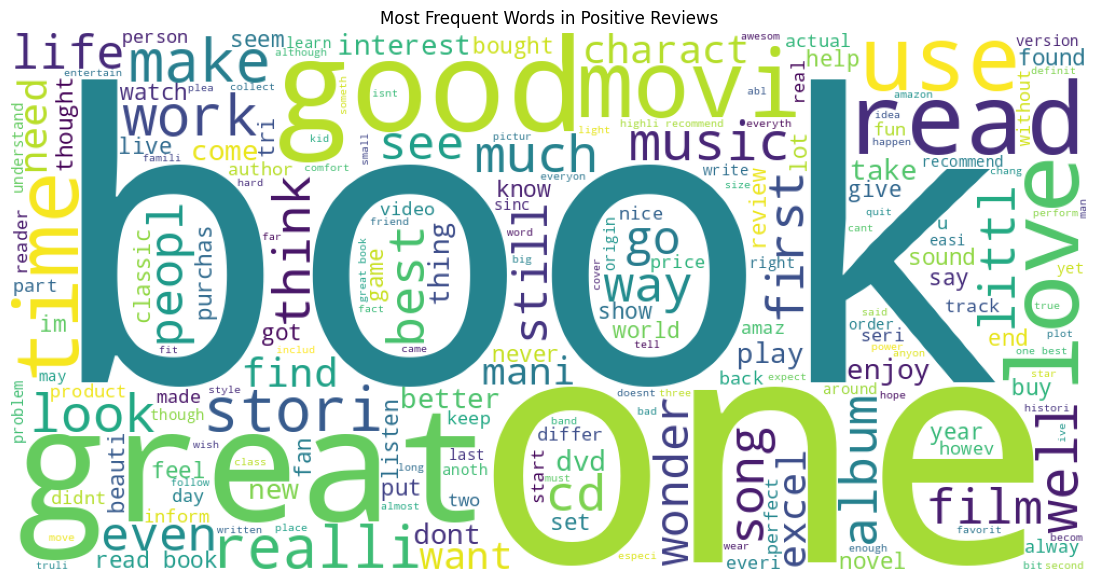

In [27]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Positive Reviews")

plt.show()

In [ ]:
## Word Cloud for Negative Reviews

In [28]:
negative_text = " ".join(
    df[df["label"] == "neg"]["clean_review"]
)

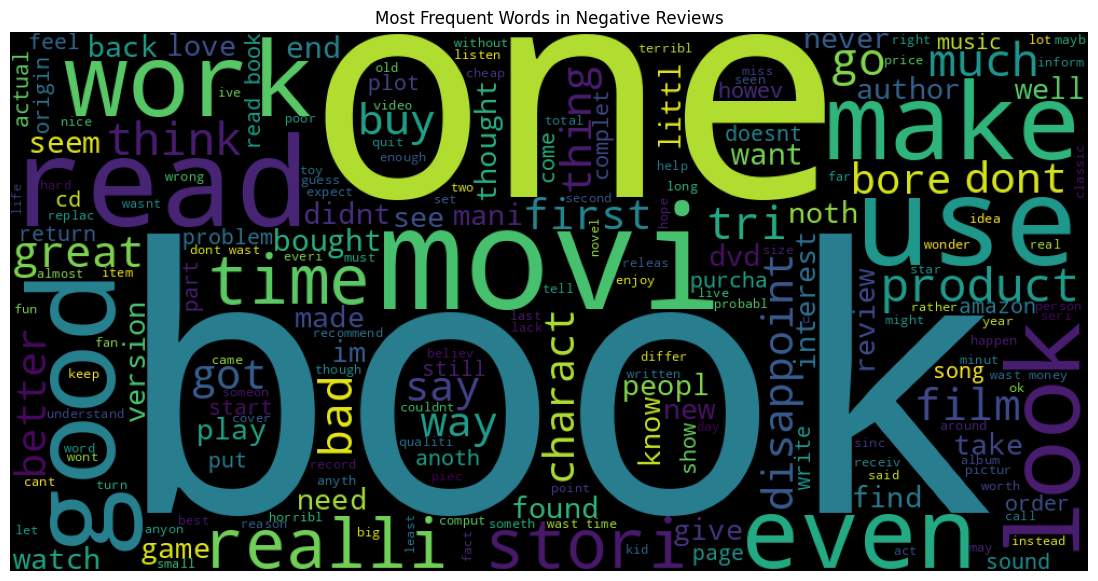

In [29]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Negative Reviews")

plt.show()

In [ ]:
## Observations

After preprocessing:

- All reviews were converted to lowercase.
- HTML tags, URLs, punctuation, and numbers were removed.
- Stopwords were removed to retain meaningful words.
- Stemming reduced words to their root forms.
- A new column named **clean_review** was created for further feature extraction.
- Word clouds provide a visual summary of the most frequent terms in positive and negative reviews.

In [ ]:
# Feature Engineering using TF-IDF

Machine Learning algorithms cannot understand raw text directly.

Therefore, the customer reviews are converted into numerical vectors using **TF-IDF (Term Frequency - Inverse Document Frequency)**.

TF-IDF assigns higher importance to words that are unique and informative while reducing the influence of very common words.

In [30]:
tfidf = TfidfVectorizer(max_features=5000)

In [31]:
X = tfidf.fit_transform(df["clean_review"])

y = df["label"]

In [32]:
print("Shape of Feature Matrix:", X.shape)

Shape of Feature Matrix: (10000, 5000)


In [ ]:
#Explanation

10000 Reviews

↓

Each converted into

↓

5000 numerical features

In [ ]:
# Train-Test Split

The dataset is divided into training and testing sets.

Training Data → Used to train the machine learning model.

Testing Data → Used to evaluate the performance of the trained model on unseen reviews.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
print("Training Samples:", X_train.shape)

print("Testing Samples:", X_test.shape)

Training Samples: (8000, 5000)
Testing Samples: (2000, 5000)


In [ ]:
# Logistic Regression Model

Logistic Regression is one of the most effective baseline algorithms for binary text classification.

It is fast, efficient, and performs well with TF-IDF features.

In [36]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

In [ ]:
# Logistic Regression Evaluation

In [37]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Accuracy: {logistic_accuracy:.4f}")

Accuracy: 0.8435


In [38]:
print(classification_report(
    y_test,
    logistic_predictions
))

              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1019
         pos       0.84      0.84      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [ ]:
#Explanation

Precision

Recall

F1 Score

Support

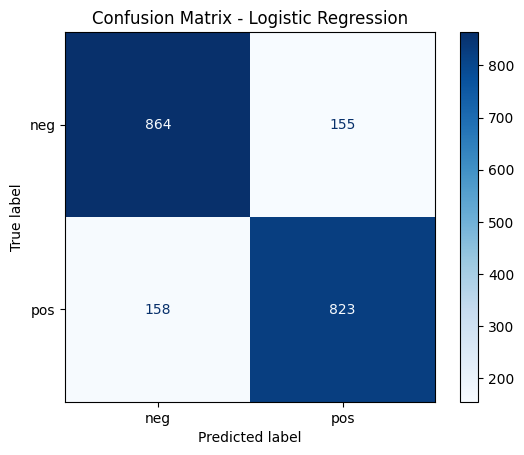

In [39]:
cm = confusion_matrix(
    y_test,
    logistic_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
# Cross Validation

Cross-validation evaluates the stability and generalization ability of the model by training and testing it on multiple subsets of the data.

In [40]:
cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:\n")

print(cv_scores)

print("\nAverage CV Accuracy:", cv_scores.mean())

Cross Validation Scores:

[0.8485 0.822  0.819  0.8225 0.85  ]

Average CV Accuracy: 0.8324


In [ ]:
# Support Vector Machine (Linear SVM)

Support Vector Machine is a powerful algorithm for text classification.

When combined with TF-IDF features, Linear SVM often achieves higher accuracy than Logistic Regression.

In [41]:
svm_model = LinearSVC()

svm_model.fit(
    X_train,
    y_train
)

LinearSVC()

In [42]:
svm_predictions = svm_model.predict(
    X_test
)

In [43]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8345


In [44]:
print(classification_report(
    y_test,
    svm_predictions
))

              precision    recall  f1-score   support

         neg       0.84      0.83      0.84      1019
         pos       0.82      0.84      0.83       981

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



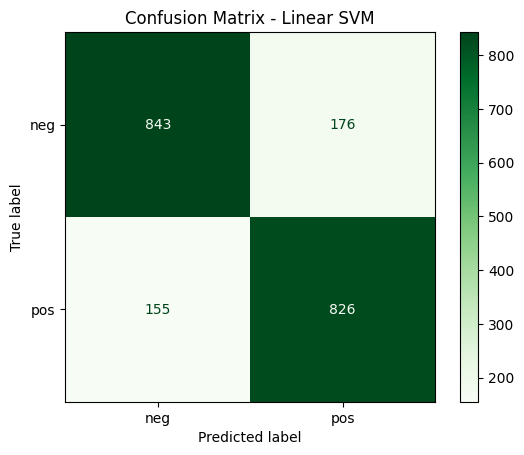

In [45]:
cm = confusion_matrix(
    y_test,
    svm_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [ ]:
# Model Comparison

In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        svm_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.8435
1,Linear SVM,0.8345


In [47]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.8435
1,Linear SVM,0.8345


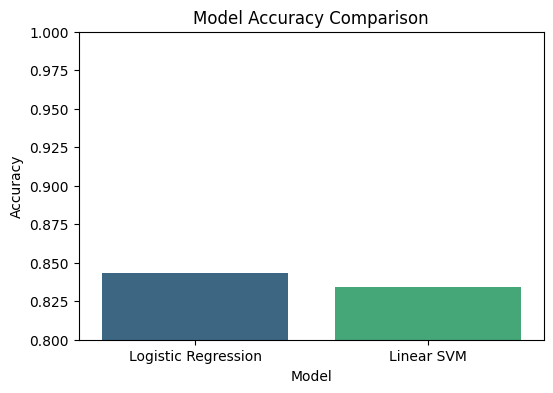

In [48]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.ylim(0.80,1.00)

plt.title("Model Accuracy Comparison")

plt.show()

In [ ]:
# Saving the Trained Model

After training the machine learning model, it is saved to disk so that it can be reused without retraining.

This allows the model to be deployed in web applications and other production environments.

In [49]:
import joblib

In [50]:
joblib.dump(logistic_model, "sentiment_model.pkl")

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [51]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer saved successfully.")

TF-IDF Vectorizer saved successfully.


In [ ]:
# Load Saved Model

The saved model and vectorizer can be loaded later for making predictions without retraining.

In [52]:
loaded_model = joblib.load("sentiment_model.pkl")

loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [ ]:
# Prediction Function

To make the model reusable, a prediction function is created.

The function:

- Accepts a customer review
- Applies the same preprocessing used during training
- Converts the review into TF-IDF features
- Predicts the sentiment
- Displays prediction confidence

In [53]:
def predict_sentiment(review):

    cleaned_review = preprocess_text(review)

    vectorized_review = loaded_vectorizer.transform([cleaned_review])

    prediction = loaded_model.predict(vectorized_review)[0]

    probability = loaded_model.predict_proba(vectorized_review)[0]

    confidence = probability.max()

    sentiment = "Positive 😊" if prediction == "pos" else "Negative 😞"

    print("=" * 60)
    print("Original Review:\n")
    print(review)
    print("=" * 60)
    print("Predicted Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2%}")

In [ ]:
# Test Prediction – Positive Review

In [54]:
positive_review = """
This product exceeded my expectations.
The quality is amazing and delivery was very fast.
I would definitely recommend it to everyone.
"""

predict_sentiment(positive_review)

Original Review:


This product exceeded my expectations.
The quality is amazing and delivery was very fast.
I would definitely recommend it to everyone.

Predicted Sentiment: Positive 😊
Confidence: 89.42%


In [ ]:
# Test Prediction – Negative Review

In [55]:
negative_review = """
This is the worst product I have ever purchased.
Poor quality and complete waste of money.
Very disappointed.
"""

predict_sentiment(negative_review)

Original Review:


This is the worst product I have ever purchased.
Poor quality and complete waste of money.
Very disappointed.

Predicted Sentiment: Negative 😞
Confidence: 99.97%


In [ ]:
# Test Prediction – Custom Review

In [56]:
my_review = input("Enter an Amazon Review:\n")

predict_sentiment(my_review)

Enter an Amazon Review:
the product was ok
Original Review:

the product was ok
Predicted Sentiment: Negative 😞
Confidence: 86.27%


In [ ]:
# Model Summary

In [57]:
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [logistic_accuracy, svm_accuracy]
})

best_model = summary.loc[summary["Accuracy"].idxmax()]

summary

,Model,Accuracy
0,Logistic Regression,0.8435
1,Linear SVM,0.8345


In [58]:
print("Best Performing Model")
print("-" * 30)

print(f"Model : {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.4f}")

Best Performing Model
------------------------------
Model : Logistic Regression
Accuracy : 0.8435


In [ ]:
# Conclusion

This project successfully developed a machine learning model capable of classifying Amazon product reviews into positive and negative sentiments.

Key achievements include:

- Performed exploratory data analysis (EDA)
- Applied text preprocessing techniques
- Converted text into TF-IDF features
- Trained Logistic Regression and Linear SVM models
- Evaluated models using accuracy, classification report, confusion matrix, and cross-validation
- Saved the trained model and TF-IDF vectorizer
- Developed a reusable sentiment prediction function

The project demonstrates the practical application of Natural Language Processing (NLP) and Machine Learning for sentiment analysis and serves as a strong foundation for deployment as a web application.

In [ ]:
# Future Enhancements

Possible future improvements include:

- Deploy the model using Streamlit
- Train deep learning models such as LSTM or BERT
- Support multilingual sentiment analysis
- Perform aspect-based sentiment analysis
- Integrate with Amazon product APIs
- Deploy using Docker and cloud platforms

In [ ]:
# Feature Importance

The coefficients learned by Logistic Regression indicate which words contribute most strongly toward positive or negative sentiment.

Positive coefficients increase the probability of a positive review.

Negative coefficients increase the probability of a negative review.

In [59]:
feature_names = tfidf.get_feature_names_out()

coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

In [60]:
top_positive = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

top_positive

,Word,Coefficient
1951,great,7.242774
2628,love,5.484057
1535,excel,4.925092
409,best,4.020933
3206,perfect,3.831622
1911,good,3.588141
142,amaz,3.141892
1368,easi,3.025440
4846,well,3.008176
1632,favorit,2.934474


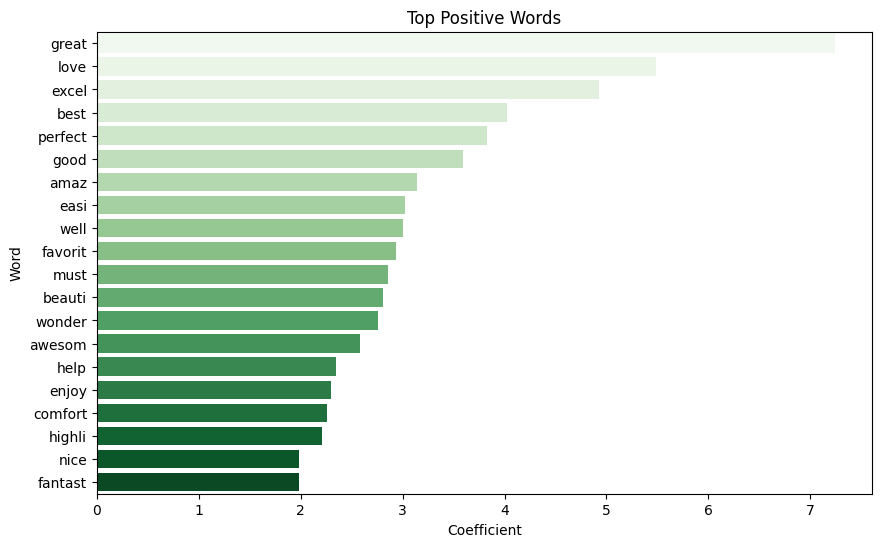

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Word",
    hue="Word",
    palette="Greens",
    legend=False
)

plt.title("Top Positive Words")

plt.show()

In [ ]:
# This shows which words helped the model classify reviews as positive.

excellent

amazing

love

perfect

great

In [62]:
top_negative = feature_importance.sort_values(
    by="Coefficient"
).head(20)

top_negative

,Word,Coefficient
1217,disappoint,-5.908285
4819,wast,-5.007455
491,bore,-4.932089
319,bad,-4.293803
3309,poor,-4.204694
4931,worst,-4.185393
1279,dont,-3.467309
2845,money,-3.457397
2138,horribl,-3.184621
3667,return,-3.075510


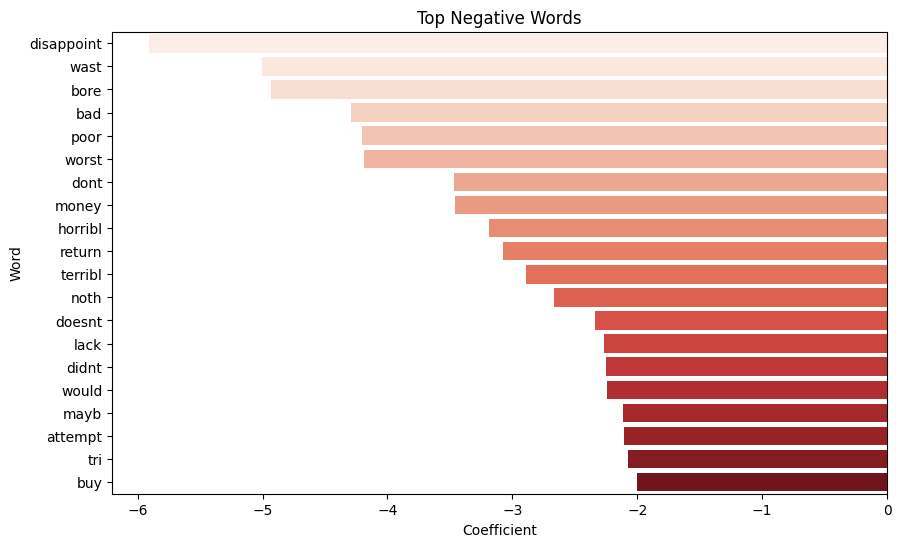

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Word",
    hue="Word",
    palette="Reds",
    legend=False
)

plt.title("Top Negative Words")

plt.show()

In [ ]:
This shows which words helped the model classify reviews as Negative


In [ ]:
# Batch Prediction

Sometimes we need to predict the sentiment of multiple customer reviews at once.

Instead of predicting one review at a time, we can process an entire list.

In [64]:
def batch_predict(reviews):

    cleaned_reviews = [preprocess_text(r) for r in reviews]

    vectors = loaded_vectorizer.transform(cleaned_reviews)

    predictions = loaded_model.predict(vectors)

    result = pd.DataFrame({
        "Review": reviews,
        "Prediction": predictions
    })

    result["Prediction"] = result["Prediction"].map({
        "pos": "Positive 😊",
        "neg": "Negative 😞"
    })

    return result

In [65]:
sample_reviews = [

    "Amazing quality. Loved it.",

    "Waste of money.",

    "Very useful product.",

    "Terrible customer support.",

    "Fantastic experience."
]

batch_predict(sample_reviews)

,Review,Prediction
0,Amazing quality. Loved it.,Positive 😊
1,Waste of money.,Negative 😞
2,Very useful product.,Negative 😞
3,Terrible customer support.,Negative 😞
4,Fantastic experience.,Positive 😊


In [ ]:
# Save Model Evaluation Results

The evaluation metrics are saved for future reference and can be included in reports or dashboards.

In [66]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy":[
        logistic_accuracy,
        svm_accuracy
    ]

})

results.to_csv(
    "model_results.csv",
    index=False
)

results

,Model,Accuracy
0,Logistic Regression,0.8435
1,Linear SVM,0.8345


In [ ]:
# Final Project Summary

This project successfully demonstrates an end-to-end Natural Language Processing workflow.

Project Pipeline

Amazon Reviews

↓

EDA

↓

Cleaning

↓

Preprocessing

↓

TF-IDF

↓

Logistic Regression

↓

Linear SVM

↓

Evaluation

↓

Model Saving

↓

Prediction

↓

Batch Prediction

↓

Ready for Deployment

In [72]:
import os
import joblib

# Create model folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# Save trained Logistic Regression model
joblib.dump(logistic_model, "model/sentiment_model.pkl")

# Save TF-IDF Vectorizer
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")

print("✅ Logistic Regression model saved successfully!")
print("✅ TF-IDF Vectorizer saved successfully!")

✅ Logistic Regression model saved successfully!
✅ TF-IDF Vectorizer saved successfully!
